In [ ]:
!pip install pyspark

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving FIFA - World Cup Summary (1).csv to FIFA - World Cup Summary (1).csv


In [ ]:
df.limit(20).toPandas()

,YEAR,HOST,CHAMPION,RUNNER UP,THIRD PLACE,TEAMS,MATCHES PLAYED,GOALS SCORED,AVG GOALS PER GAME
0,1930,Uruguay,Uruguay,Argentina,United States,13,16,70,3.6
1,1934,Italy,Italy,Czechoslovakia,Germany,16,17,70,4.1
2,1938,France,Italy,Hungary,Brazil,15,18,84,4.7
3,1950,Brazil,Uruguay,Brazil,Sweden,13,22,88,4.0
4,1954,Switzerland,West Germany,Hungary,Austria,16,26,140,5.4
5,1958,Sweden,Brazil,Sweden,France,16,35,126,3.6
6,1962,Chile,Brazil,Czechoslovakia,Chile,16,32,89,2.8
7,1966,England,England,West Germany,Portugal,16,32,89,2.8
8,1970,Mexico,Brazil,Italy,West Germany,16,32,95,3.0
9,1974,West Germany,West Germany,Netherlands,Poland,16,38,97,2.6


In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *

import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
spark = SparkSession.builder \
    .appName("FIFA_BigData_Analysis") \
    .getOrCreate()

print("Spark Session Created Successfully")

Spark Session Created Successfully


In [ ]:
df = spark.read.csv(
    'FIFA - World Cup Summary (1).csv',
    header=True,
    inferSchema=True
)

In [ ]:
df.limit(10).toPandas()

,YEAR,HOST,CHAMPION,RUNNER UP,THIRD PLACE,TEAMS,MATCHES PLAYED,GOALS SCORED,AVG GOALS PER GAME
0,1930,Uruguay,Uruguay,Argentina,United States,13,16,70,3.6
1,1934,Italy,Italy,Czechoslovakia,Germany,16,17,70,4.1
2,1938,France,Italy,Hungary,Brazil,15,18,84,4.7
3,1950,Brazil,Uruguay,Brazil,Sweden,13,22,88,4.0
4,1954,Switzerland,West Germany,Hungary,Austria,16,26,140,5.4
5,1958,Sweden,Brazil,Sweden,France,16,35,126,3.6
6,1962,Chile,Brazil,Czechoslovakia,Chile,16,32,89,2.8
7,1966,England,England,West Germany,Portugal,16,32,89,2.8
8,1970,Mexico,Brazil,Italy,West Germany,16,32,95,3.0
9,1974,West Germany,West Germany,Netherlands,Poland,16,38,97,2.6


In [ ]:
print("Total Rows :", df.count())
print("Total Columns :", len(df.columns))

Total Rows : 21
Total Columns : 9


In [ ]:
null_values = df.select([
    count(
        when(col(c).isNull(), c)
    ).alias(c)
    for c in df.columns
])

null_values.toPandas()


,YEAR,HOST,CHAMPION,RUNNER UP,THIRD PLACE,TEAMS,MATCHES PLAYED,GOALS SCORED,AVG GOALS PER GAME
0,0,0,0,0,0,0,0,0,0


In [ ]:
top_world_cups = df.select(
    "YEAR",
    "HOST",
    "CHAMPION",
    "GOALS SCORED"
).orderBy(
    col("GOALS SCORED").desc()
)

top_world_cups.limit(10).toPandas()

,YEAR,HOST,CHAMPION,GOALS SCORED
0,2014,Brazil,Germany,171
1,1998,France,France,171
2,2018,Russia,France,169
3,2002,"South Korea, Japan",Brazil,161
4,2006,Germany,Italy,147
5,1982,Spain,Italy,146
6,2010,South Africa,Spain,145
7,1994,United States,Brazil,141
8,1954,Switzerland,West Germany,140
9,1986,Mexico,Argentina,132


In [ ]:
top_champions_by_goals = df.groupBy("CHAMPION")\
    .agg(sum("GOALS SCORED").alias("Total Goals Scored"))\
    .orderBy(col("Total Goals Scored").desc())

top_champions_by_goals.limit(10).toPandas()

,CHAMPION,Total Goals Scored
0,Brazil,612
1,Italy,447
2,West Germany,352
3,France,340
4,Argentina,234
5,Germany,171
6,Uruguay,158
7,Spain,145
8,England,89


In [ ]:
champion_analysis = df.groupBy(
    "CHAMPION"
).count().orderBy(
    col("count").desc()
)

champion_analysis.limit(10).toPandas()

,CHAMPION,count
0,Brazil,5
1,Italy,4
2,West Germany,3
3,France,2
4,Argentina,2
5,Uruguay,2
6,Germany,1
7,Spain,1
8,England,1


In [ ]:
host_goals_analysis = df.groupBy(
    "HOST"
).agg(
    avg("GOALS SCORED").alias("Average_Goals_Scored")
).orderBy(
    col("Average_Goals_Scored").desc()
)

host_goals_analysis.limit(10).toPandas()

,HOST,Average_Goals_Scored
0,Russia,169.0
1,"South Korea, Japan",161.0
2,Germany,147.0
3,Spain,146.0
4,South Africa,145.0
5,United States,141.0
6,Switzerland,140.0
7,Brazil,129.5
8,France,127.5
9,Sweden,126.0


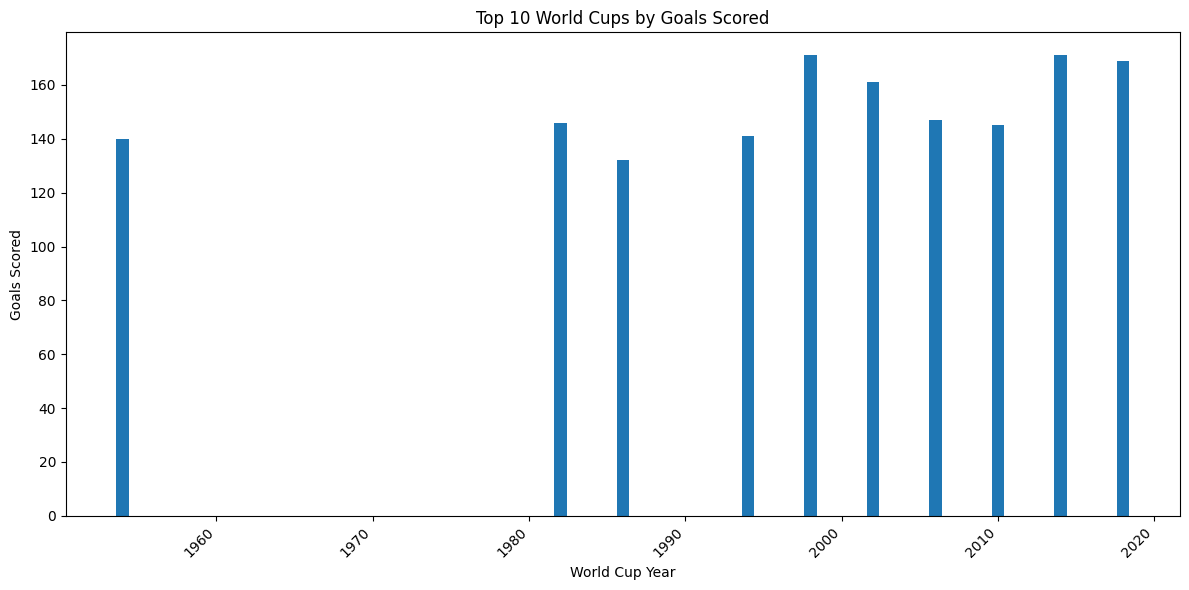

In [ ]:
world_cup_goals_data = top_world_cups.limit(10).toPandas()

plt.figure(figsize=(12,6))

plt.bar(
    world_cup_goals_data['YEAR'],
    world_cup_goals_data['GOALS SCORED']
)

plt.title("Top 10 World Cups by Goals Scored")

plt.xlabel("World Cup Year")
plt.ylabel("Goals Scored")

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
runner_up_analysis = df.groupBy(
    "RUNNER UP"
).count().orderBy(
    col("count").desc()
)

runner_up_analysis.toPandas()

,RUNNER UP,count
0,Argentina,3
1,West Germany,3
2,Netherlands,3
3,Czechoslovakia,2
4,Italy,2
5,Brazil,2
6,Hungary,2
7,Sweden,1
8,Germany,1
9,France,1


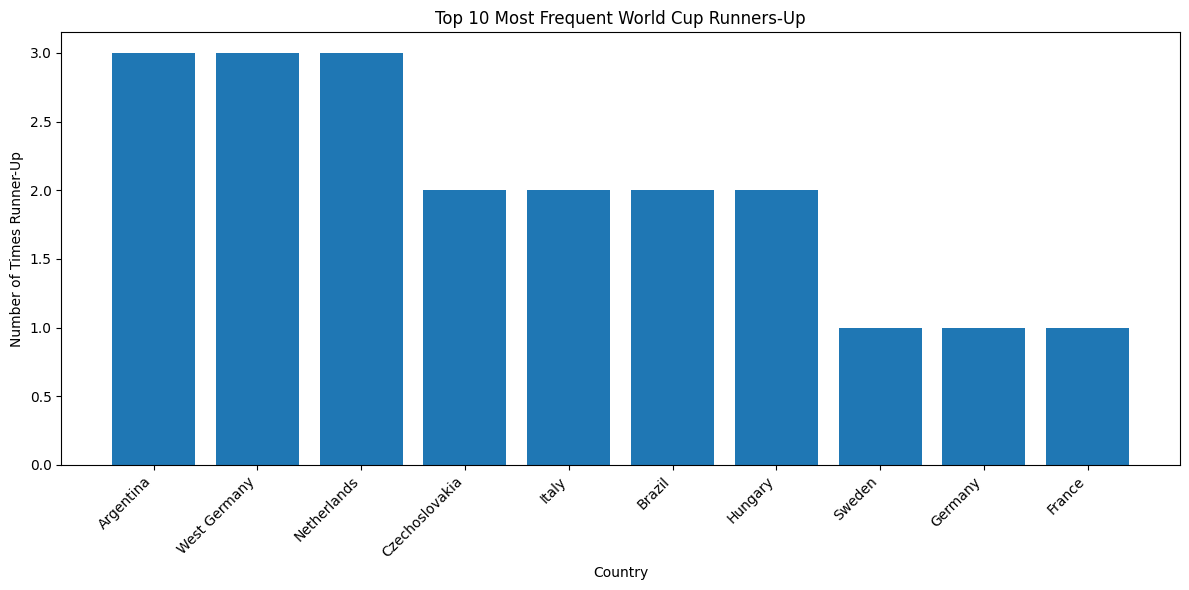

In [ ]:
runner_up_plot_data = runner_up_analysis.limit(10).toPandas()

plt.figure(figsize=(12, 6))

plt.bar(
    runner_up_plot_data['RUNNER UP'],
    runner_up_plot_data['count']
)

plt.xticks(rotation=45, ha='right')

plt.title("Top 10 Most Frequent World Cup Runners-Up")

plt.xlabel("Country")
plt.ylabel("Number of Times Runner-Up")

plt.tight_layout()
plt.show()

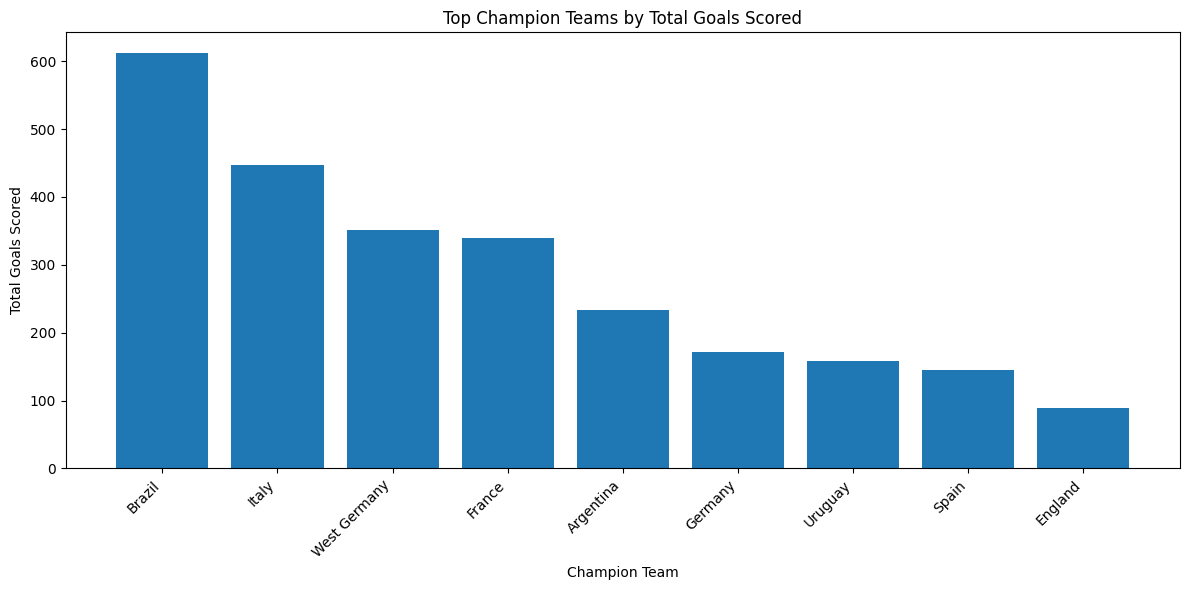

In [ ]:
champions_goals_plot_data = top_champions_by_goals.limit(10).toPandas()

plt.figure(figsize=(12, 6))

plt.bar(
    champions_goals_plot_data['CHAMPION'],
    champions_goals_plot_data['Total Goals Scored']
)

plt.xticks(rotation=45, ha='right')

plt.title("Top Champion Teams by Total Goals Scored")

plt.xlabel("Champion Team")
plt.ylabel("Total Goals Scored")

plt.tight_layout()
plt.show()

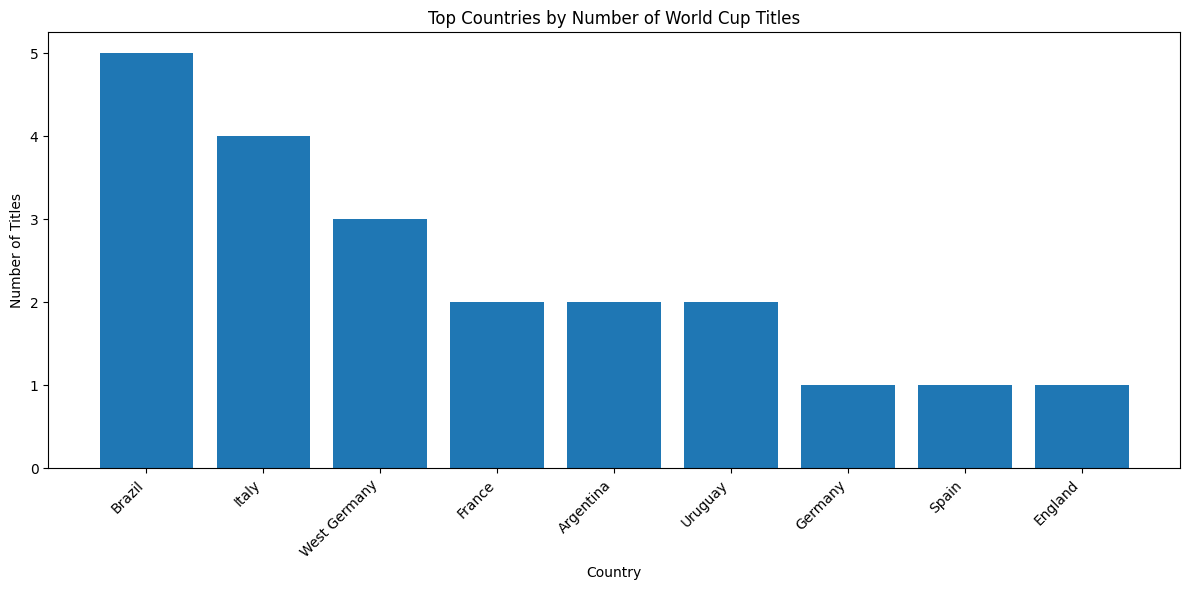

In [ ]:
champion_plot_data = champion_analysis.limit(10).toPandas()

plt.figure(figsize=(12, 6))

plt.bar(
    champion_plot_data['CHAMPION'],
    champion_plot_data['count']
)

plt.xticks(rotation=45, ha='right')

plt.title("Top Countries by Number of World Cup Titles")

plt.xlabel("Country")

plt.ylabel("Number of Titles")

plt.tight_layout()
plt.show()

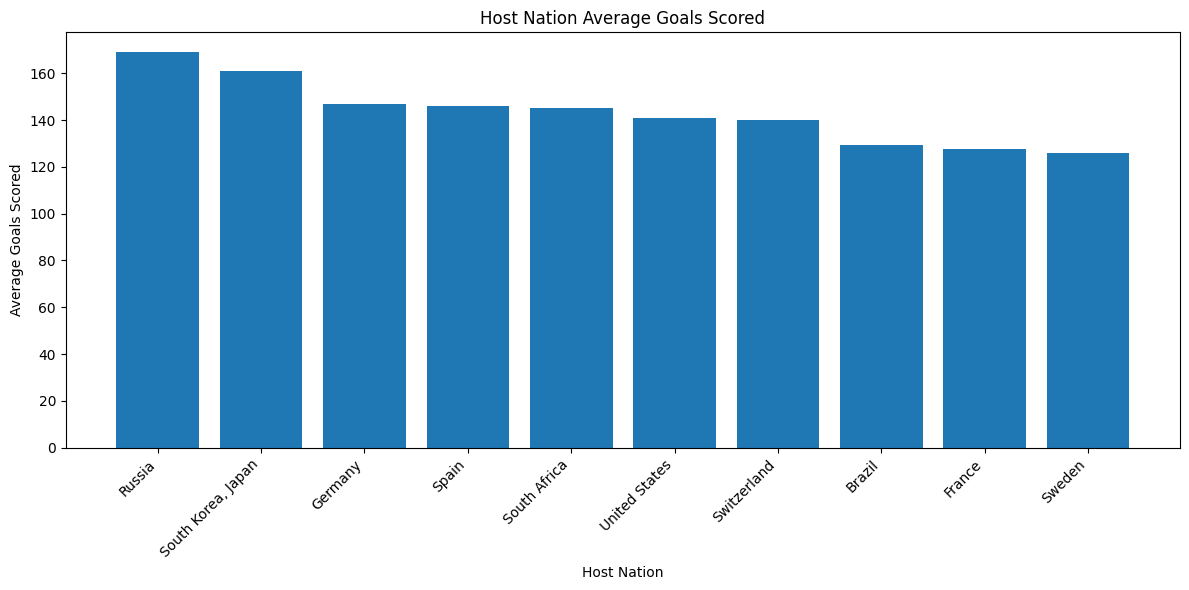

In [ ]:
host_goals_plot_data = host_goals_analysis.limit(10).toPandas()

plt.figure(figsize=(12, 6))

plt.bar(
    host_goals_plot_data['HOST'],
    host_goals_plot_data['Average_Goals_Scored']
)

plt.xticks(rotation=45, ha='right')

plt.title("Host Nation Average Goals Scored")

plt.xlabel("Host Nation")
plt.ylabel("Average Goals Scored")

plt.tight_layout()
plt.show()

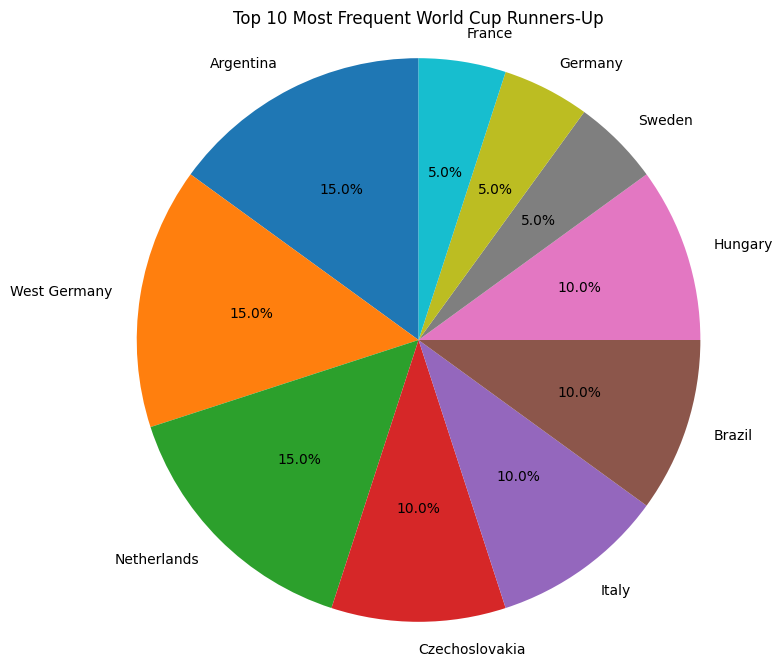

In [ ]:
runner_up_pie_data = runner_up_analysis.limit(10).toPandas()

plt.figure(figsize=(8,8))

plt.pie(
    runner_up_pie_data['count'],
    labels=runner_up_pie_data['RUNNER UP'],
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Top 10 Most Frequent World Cup Runners-Up")

plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

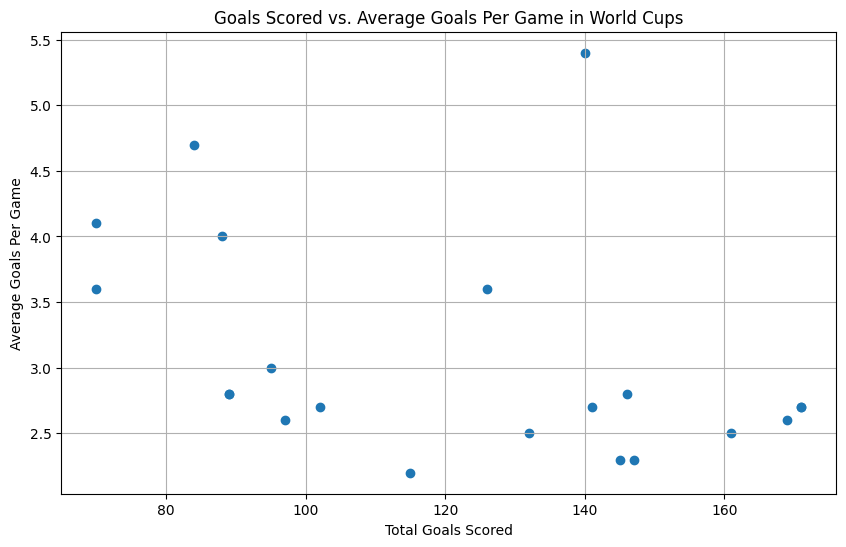

In [ ]:
scatter_data_world_cups = df.select(
    "GOALS SCORED",
    "AVG GOALS PER GAME",
    "YEAR"
).toPandas()

plt.figure(figsize=(10,6))

plt.scatter(
    scatter_data_world_cups['GOALS SCORED'],
    scatter_data_world_cups['AVG GOALS PER GAME']
)

plt.title("Goals Scored vs. Average Goals Per Game in World Cups")

plt.xlabel("Total Goals Scored")

plt.ylabel("Average Goals Per Game")

plt.grid(True)
plt.show()

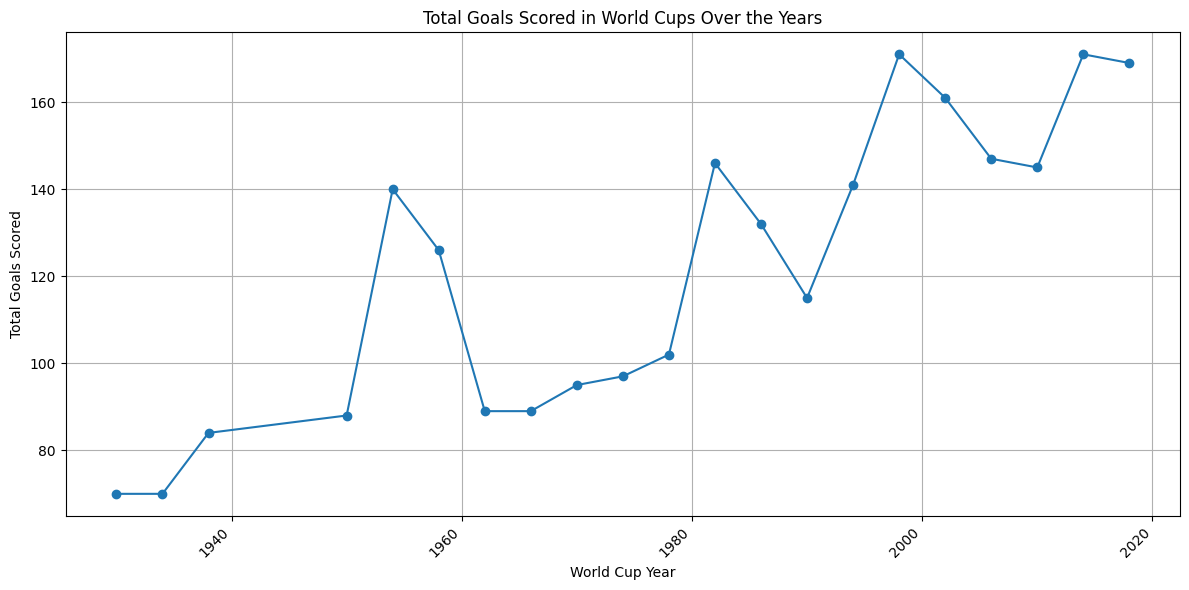

In [ ]:
goals_over_years_data = df.select(
    "YEAR",
    "GOALS SCORED"
).orderBy(
    "YEAR"
).toPandas()

plt.figure(figsize=(12, 6))

plt.plot(
    goals_over_years_data['YEAR'],
    goals_over_years_data['GOALS SCORED'],
    marker='o'
)

plt.title("Total Goals Scored in World Cups Over the Years")
plt.xlabel("World Cup Year")
plt.ylabel("Total Goals Scored")
plt.grid(True)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()